# Notebook 02: Hybrid MIL Patch Extraction
**Goal:** Extract patches from full mammograms and ROI crops using a hybrid 
strategy, then save patch arrays and a leak-free patient-level train/val split 
for downstream model training.

In [1]:
import sys
sys.path.append(
    '/kaggle/input/datasets/mfjmrizvi/cbis-ddsm-project-config'
)
import config as cfg
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import json
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf

print(f"TensorFlow: {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")
print(f"\nConfig loaded")
print(f"  PATCH_SIZE:  {cfg.PATCH_SIZE}")
print(f"  STRIDE:      {cfg.STRIDE}")
print(f"  MIN_STD:     {cfg.MIN_STD}")
print(f"  MAX_PATCHES: {cfg.MAX_PATCHES}")
print(f"  RANDOM_SEED: {cfg.RANDOM_SEED}")

NB01   = '/kaggle/input/notebooks/mfjmrizvi/01-dataset-setup-and-eda'
OUTPUT = '/kaggle/working'

Config loaded successfully


2026-08-16 18:35:10.556707: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786905310.738504      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786905310.788197      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786905311.200222      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786905311.200263      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786905311.200266      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Config loaded
  PATCH_SIZE:  224
  STRIDE:      112
  MIN_STD:     15
  MAX_PATCHES: 48
  RANDOM_SEED: 42


## 1. Load Linked Metadata
Load the cleaned, path-linked CSVs produced by Notebook 01.

In [2]:
# Cell 2 — Load linked CSVs from Notebook 01

mass_train = pd.read_csv(f'{NB01}/mass_train_linked.csv')  # now 1318 rows, has 'fold'
mass_test  = pd.read_csv(f'{NB01}/mass_test_linked.csv')

print(f"mass_train: {mass_train.shape}  (fold values: {sorted(mass_train['fold'].unique())})")
print(f"mass_test:  {mass_test.shape}")
print(f"\nLabel distribution (train):")
print(mass_train['label'].value_counts())
print(f"\nFull image paths linked:    "
      f"{mass_train['full_image_path'].notna().sum()}")
print(f"Cropped image paths linked: "
      f"{mass_train['cropped_image_path'].notna().sum()}")

mass_train: (1226, 19)  (fold values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)])
mass_test:  (365, 18)

Label distribution (train):
label
1    617
0    609
Name: count, dtype: int64

Full image paths linked:    1226
Cropped image paths linked: 1226


In [3]:
from PIL import Image
import numpy as np

img = Image.open(mass_train['full_image_path'].iloc[0])
arr = np.array(img)
print(arr.dtype, arr.min(), arr.max())

uint16 0 65535


### 2 Save Split Indices
Persisted as `.npy` files so downstream notebooks use the identical split 
without re-running this logic.

In [4]:
np.save(f'{OUTPUT}/fold_ids.npy', mass_train['fold'].values)
print(f"Saved fold_ids.npy — {len(mass_train)} entries, aligned to bag_id (row index)")

Saved fold_ids.npy — 1226 entries, aligned to bag_id (row index)


## 3. Patch Extraction Functions

Three functions implement the hybrid MIL strategy:

- `extract_patches_from_image`: grid scan over the full mammogram, filters 
  blank patches by standard deviation, then random spatial sampling
- `extract_patches_from_roi`: dense 50% overlap extraction from the 
  pre-cropped lesion region; resizes up if smaller than patch size

In [5]:
def is_mostly_tissue(patch, min_tissue_fraction=0.75, bg_threshold=0.05):
    """
    Balanced filter:
    - min_tissue_fraction = 0.75: Allows peripheral tissue (near skin/edges) 
      so lesions near margins aren't excluded, but drops patches that are 
      mostly black empty space.
    - bg_threshold = 0.05 (~13/255): Catches true background without excluding 
      faint subcutaneous tissue.
    """
    tissue_fraction = np.mean(patch > bg_threshold)
    return tissue_fraction >= min_tissue_fraction


def extract_patches_from_image(image_path, patch_size, stride,
                               min_std, max_patches, seed=42,
                               min_tissue_fraction=0.75,
                               bg_threshold=0.05,
                               exclude_corner_frac=0.08):
    try:
        img = Image.open(image_path)            
        img_array = np.array(img, dtype=np.float32) / 65535.0   # normalise by 16-bit max
        h, w = img_array.shape

        # Keep annotation exclusion small so real tissue isn't clipped
        corner_h = int(h * exclude_corner_frac)
        corner_w = int(w * exclude_corner_frac)

        valid_patches   = []
        valid_positions = []

        for r in range(0, h - patch_size + 1, stride):
            for c in range(0, w - patch_size + 1, stride):
                
                # Corner check: only skip top corners if they are predominantly dark (text overlay area)
                if r < corner_h and (c < corner_w or c > w - corner_w - patch_size):
                    # If it's mostly background, it's the tag corner; skip it
                    if np.mean(img_array[r:r+patch_size, c:c+patch_size]) < 0.20:
                        continue

                patch = img_array[r:r+patch_size, c:c+patch_size]

                # 1. Ensure patch is predominantly tissue (allows margin/subcutaneous lesions)
                if not is_mostly_tissue(patch, min_tissue_fraction=min_tissue_fraction, bg_threshold=bg_threshold):
                    continue

                # 2. Check standard deviation for texture variation
                if patch.std() * 255 < min_std:
                    continue

                valid_patches.append(patch)
                valid_positions.append((r, c))

        total = len(valid_patches)
        if total == 0:
            return None, None, 0, 0

        # Uniform random sub-sampling across ALL valid tissue patches
        if total > max_patches:
            rng = np.random.default_rng(seed)
            indices = sorted(
                rng.choice(total, max_patches, replace=False)
            )
            valid_patches   = [valid_patches[i]   for i in indices]
            valid_positions = [valid_positions[i] for i in indices]

        kept = len(valid_patches)
        patches_array = np.array(valid_patches)[..., np.newaxis]
        return patches_array, valid_positions, kept, total

    except Exception as e:
        print(f"Error (full): {image_path}: {e}")
        return None, None, 0, 0
        if total > max_patches:
            rng = np.random.default_rng(seed)
            indices = sorted(
                rng.choice(total, max_patches, replace=False)
            )
            valid_patches   = [valid_patches[i]   for i in indices]
            valid_positions = [valid_positions[i] for i in indices]

        kept = len(valid_patches)
        patches_array = np.array(valid_patches)[..., np.newaxis]
        return patches_array, valid_positions, kept, total

    except Exception as e:
        print(f"Error (full): {image_path}: {e}")
        return None, None, 0, 0

        if total > max_patches:
            rng = np.random.default_rng(seed)
            indices = sorted(
                rng.choice(total, max_patches, replace=False)
            )
            valid_patches   = [valid_patches[i]   for i in indices]
            valid_positions = [valid_positions[i] for i in indices]

        kept = len(valid_patches)
        patches_array = np.array(valid_patches)[..., np.newaxis]
        return patches_array, valid_positions, kept, total

    except Exception as e:
        print(f"Error (full): {image_path}: {e}")
        return None, None, 0, 0


def extract_patches_from_roi(cropped_path, patch_size,
                              min_std, seed=42,
                              min_tissue_fraction=0.85):
    try:
        img = Image.open(image_path)              
        img_array = np.array(img, dtype=np.float32) / 65535.0   # normalise by 16-bit max
        h, w = img_array.shape

        # Zero-pad up to patch_size on a black background —
        # no interpolation, no resampling artefacts introduced.
        if w < patch_size or h < patch_size:
            pad_h = max(patch_size - h, 0)
            pad_w = max(patch_size - w, 0)
            top    = pad_h // 2
            bottom = pad_h - top
            left   = pad_w // 2
            right  = pad_w - left
            img_array = np.pad(
                img_array,
                ((top, bottom), (left, right)),
                mode='constant',
                constant_values=0.0
            )
            h, w = img_array.shape

        valid_patches   = []
        valid_positions = []
        roi_stride = patch_size // 2  # 50% overlap for ROI

        for r in range(0, h - patch_size + 1, roi_stride):
            for c in range(0, w - patch_size + 1, roi_stride):
                patch = img_array[r:r+patch_size, c:c+patch_size]
                if patch.std() * 255 < min_std:
                    continue
                if not is_mostly_tissue(patch, min_tissue_fraction=min_tissue_fraction):
                    continue
                valid_patches.append(patch)
                valid_positions.append((r, c))

        # Fallback: centre crop if no valid patches found
        if len(valid_patches) == 0:
            r_s = max(0, (h - patch_size) // 2)
            c_s = max(0, (w - patch_size) // 2)
            patch = img_array[r_s:r_s+patch_size, c_s:c_s+patch_size]
            if patch.shape == (patch_size, patch_size):
                valid_patches.append(patch)
                valid_positions.append((r_s, c_s))

        if len(valid_patches) == 0:
            return None, None, 0

        patches_array = np.array(valid_patches)[..., np.newaxis]
        return patches_array, valid_positions, len(valid_patches)

    except Exception as e:
        print(f"Error (ROI): {cropped_path}: {e}")
        return None, None, 0


def extract_uniform_patches(row, patch_size, stride, min_std, max_patches, seed=42):
    # Uniformly samples patches across the FULL mammogram for BOTH malignant and benign cases.
    # Zero ground-truth ROI crops are used during bag generation.
    patches, _, kept, _ = extract_patches_from_image(
        row['full_image_path'],
        patch_size=patch_size,
        stride=stride,
        min_std=min_std,
        max_patches=max_patches,
        seed=seed
    )
    return patches, (kept if patches is not None else 0)


print("Patch extraction functions defined:")
print("  extract_patches_from_image: full mammogram grid sampling (tissue-content filtered, corner-excluded)")
print("  extract_patches_from_roi: ROI crop dense sampling (tissue-content filtered)")
print("  extract_uniform_patches : hybrid MIL strategy")

Patch extraction functions defined:
  extract_patches_from_image: full mammogram grid sampling (tissue-content filtered, corner-excluded)
  extract_patches_from_roi: ROI crop dense sampling (tissue-content filtered)
  extract_uniform_patches : hybrid MIL strategy


## 4. Extraction Sanity Check
Test on one malignant and one benign image before running the full set.

In [6]:
print("SINGLE IMAGE EXTRACTION TEST")

for label_val, label_name in [(1, 'MALIGNANT'), (0, 'BENIGN')]:
    sample = mass_train[mass_train['label'] == label_val].iloc[0]
    patches, kept = extract_uniform_patches(
        sample,
        cfg.PATCH_SIZE, cfg.STRIDE, cfg.MIN_STD, cfg.MAX_PATCHES
    )
    print(f"{label_name}:")
    print(f"  patient_id:     {sample['patient_id']}")
    print(f"  patches kept:   {kept}")
    if patches is not None:
        print(f"  array shape:    {patches.shape}")
        print(f"  pixel range:    "
              f"{patches.min():.3f} - {patches.max():.3f}")
        print(f"  mean pixel val: {patches.mean():.3f}")
    print()

SINGLE IMAGE EXTRACTION TEST
MALIGNANT:
  patient_id:     P_00001
  patches kept:   48
  array shape:    (48, 224, 224, 1)
  pixel range:    0.000 - 1.000
  mean pixel val: 0.419

BENIGN:
  patient_id:     P_00004
  patches kept:   48
  array shape:    (48, 224, 224, 1)
  pixel range:    0.000 - 0.874
  mean pixel val: 0.323



## 5. Visual Verification
Confirm the hybrid strategy produces visually meaningful patches. 
ROI coverage for malignant, spatial spread for benign.

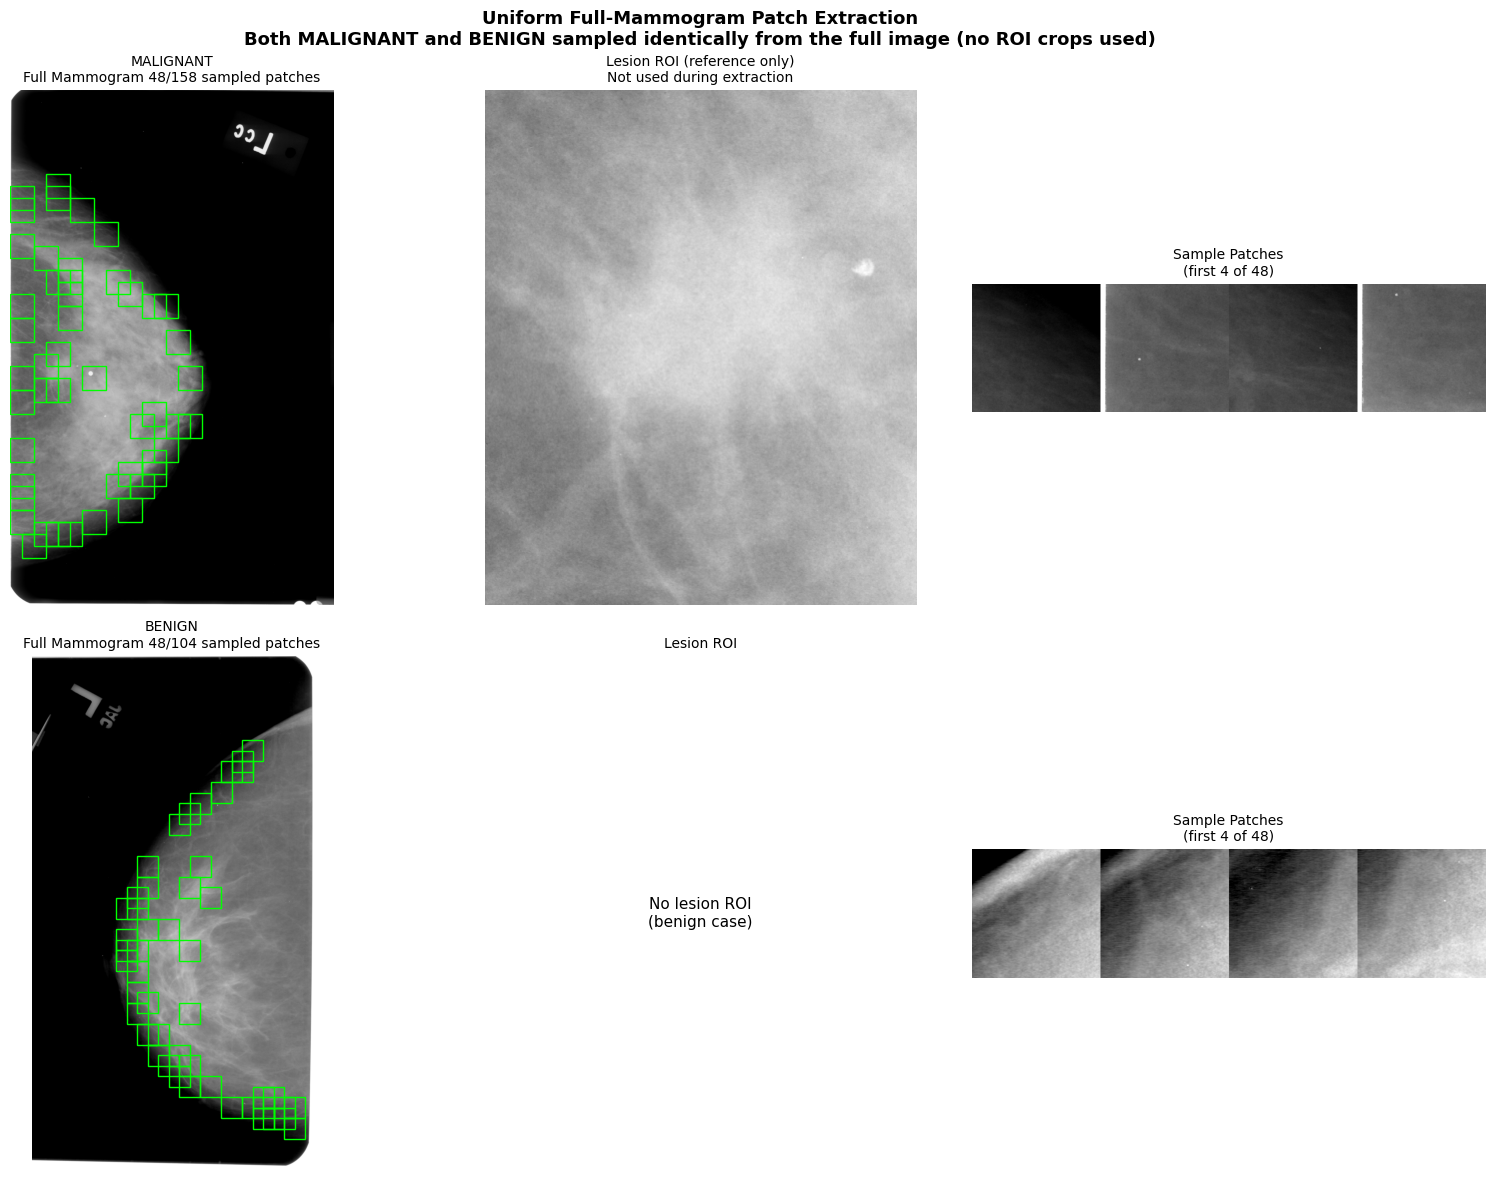

Visualisation saved


In [8]:
malignant_row = mass_train[mass_train['label'] == 1].iloc[0]
benign_row    = mass_train[mass_train['label'] == 0].iloc[0]

fig, axes = plt.subplots(2, 3, figsize=(16, 12))
fig.suptitle(
    'Uniform Full-Mammogram Patch Extraction\n'
    'Both MALIGNANT and BENIGN sampled identically from the full image (no ROI crops used)',
    fontsize=13, fontweight='bold'
)

for row_idx, (row, label_name) in enumerate(
        [(malignant_row, 'MALIGNANT'), (benign_row, 'BENIGN')]):

    # Use the lower-level function directly so we get patch positions back,
    # letting us verify visually whether sampled patches land near the lesion.
    patches, positions, kept, total = extract_patches_from_image(
        row['full_image_path'],
        patch_size=cfg.PATCH_SIZE,
        stride=cfg.STRIDE,
        min_std=cfg.MIN_STD,
        max_patches=cfg.MAX_PATCHES,
        seed=cfg.RANDOM_SEED
    )

    img_full = np.array(Image.open(row['full_image_path']), dtype=np.float32) / 65535.0

    # Column 0: full mammogram with sampled patch locations overlaid
    axes[row_idx, 0].imshow(img_full, cmap='gray', vmin=0, vmax=1)
    if positions is not None:
        for (r, c) in positions:
            rect = mpatches.Rectangle(
                (c, r), cfg.PATCH_SIZE, cfg.PATCH_SIZE,
                linewidth=1, edgecolor='lime', facecolor='none'
            )
            axes[row_idx, 0].add_patch(rect)
    axes[row_idx, 0].set_title(
        f'{label_name}\nFull Mammogram {kept}/{total} sampled patches',
        fontsize=10
    )
    axes[row_idx, 0].axis('off')

    # Column 1: cropped ROI shown as visual reference only (NOT used in extraction)
    # — helps eyeball whether sampled patches (col 0, green boxes) overlap the lesion.
    if label_name == 'MALIGNANT':
        img_roi = np.array(Image.open(row['cropped_image_path']), dtype=np.float32) / 65535.0
        axes[row_idx, 1].imshow(img_roi, cmap='gray', vmin=0, vmax=1)
        axes[row_idx, 1].set_title(
            'Lesion ROI (reference only)\nNot used during extraction',
            fontsize=10
        )
    else:
        axes[row_idx, 1].text(
            0.5, 0.5, 'No lesion ROI\n(benign case)',
            ha='center', va='center', fontsize=11,
            transform=axes[row_idx, 1].transAxes
        )
        axes[row_idx, 1].set_title('Lesion ROI', fontsize=10)
    axes[row_idx, 1].axis('off')

    # Column 2: patch grid first few sampled patches
    if patches is not None and kept > 0:
        n_show = min(4, kept)
        grid = np.zeros((cfg.PATCH_SIZE, cfg.PATCH_SIZE * n_show))
        for i in range(n_show):
            grid[:, i*cfg.PATCH_SIZE:(i+1)*cfg.PATCH_SIZE] = \
                patches[i, :, :, 0]
        axes[row_idx, 2].imshow(grid, cmap='gray')
        axes[row_idx, 2].set_title(
            f'Sample Patches\n(first {n_show} of {kept})', fontsize=10)
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT}/uniform_extraction_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Visualisation saved")

## 6. Patch Yield Statistics (50 Image Sample)


PATCH YIELD STATISTICS  (50 IMAGE SAMPLE)
Failed extractions: 0

Patches per image:
count    50.0
mean     48.0
std       0.0
min      48.0
25%      48.0
50%      48.0
75%      48.0
max      48.0
Name: kept, dtype: float64

By label:
       count  mean  std   min   25%   50%   75%   max
label                                                
0       28.0  48.0  0.0  48.0  48.0  48.0  48.0  48.0
1       22.0  48.0  0.0  48.0  48.0  48.0  48.0  48.0


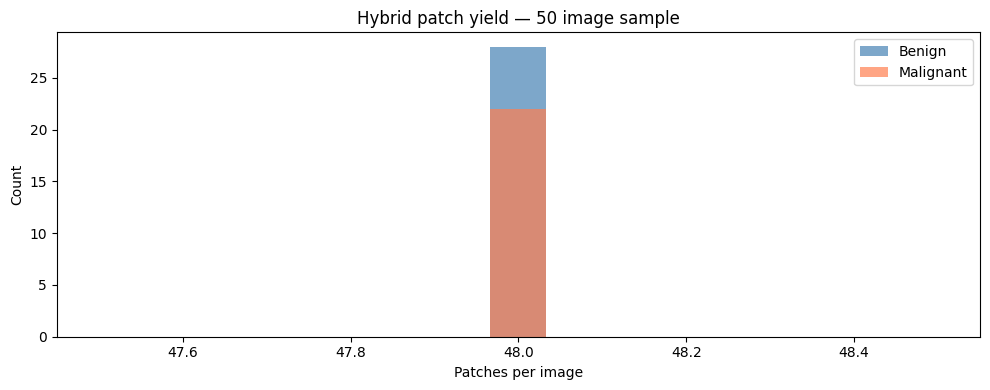

Plot saved


In [9]:
print("PATCH YIELD STATISTICS  (50 IMAGE SAMPLE)")
sample_df = mass_train.head(50)
stats = []

for _, row in sample_df.iterrows():
    patches, kept = extract_uniform_patches(
        row, cfg.PATCH_SIZE, cfg.STRIDE,
        cfg.MIN_STD, cfg.MAX_PATCHES
    )
    stats.append({
        'label':  int(row['label']),
        'kept':   kept,
        'failed': patches is None
    })

stats_df = pd.DataFrame(stats)

print(f"Failed extractions: {stats_df['failed'].sum()}")
print(f"\nPatches per image:")
print(stats_df['kept'].describe())
print(f"\nBy label:")
print(stats_df.groupby('label')['kept'].describe())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(stats_df[stats_df['label']==0]['kept'],
        bins=15, alpha=0.7, label='Benign',    color='steelblue')
ax.hist(stats_df[stats_df['label']==1]['kept'],
        bins=15, alpha=0.7, label='Malignant', color='coral')
ax.set_xlabel('Patches per image')
ax.set_ylabel('Count')
ax.set_title('Hybrid patch yield — 50 image sample')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT}/hybrid_patch_stats.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

## 7. Full Patch Extraction: Training Set


In [12]:
print("FULL HYBRID EXTRACTION: TRAINING SET")
print(f"Images to process: {len(mass_train)}")
print(f"Parameters: patch_size={cfg.PATCH_SIZE}, "
      f"stride={cfg.STRIDE}, min_std={cfg.MIN_STD}, "
      f"max_patches={cfg.MAX_PATCHES}\n")

all_patches   = []
all_labels    = []
all_bag_ids   = []
failed_images = []

for idx, row in mass_train.iterrows():
    patches, kept = extract_uniform_patches(
        row,
        cfg.PATCH_SIZE, cfg.STRIDE,
        cfg.MIN_STD, cfg.MAX_PATCHES,
        seed=cfg.RANDOM_SEED + idx
    )

    if patches is None or kept == 0:
        failed_images.append(row['patient_id'])
        continue

    all_patches.append(patches)
    all_labels.extend([int(row['label'])] * kept)
    all_bag_ids.extend([idx] * kept)

    if idx % 200 == 0:
        so_far = sum(len(p) for p in all_patches)
        print(f"  {idx}/{len(mass_train)} | "
              f"patches so far: {so_far}")

X_train       = np.concatenate(all_patches, axis=0)
y_train       = np.array(all_labels)
bag_ids_train = np.array(all_bag_ids)

# Save arrays
np.save(f'{OUTPUT}/y_train_labels.npy', y_train)
np.save(f'{OUTPUT}/bag_ids_train.npy', bag_ids_train)
np.save(f'{OUTPUT}/X_train_patches.npy', X_train)

# Capture metadata values before deleting X_train
X_train_shape  = X_train.shape
X_train_memory = X_train.nbytes / 1024**3

# Clean up heavy objects from RAM
del all_patches, X_train
import gc; gc.collect()

print(f"\n=== TRAINING EXTRACTION COMPLETE ===")
print(f"X_train shape:        {X_train_shape}")
print(f"y_train distribution: {np.bincount(y_train)}")
print(f"Failed images:        {len(failed_images)}")
print(f"Memory freed:         {X_train_memory:.2f} GB")

FULL HYBRID EXTRACTION: TRAINING SET
Images to process: 1226
Parameters: patch_size=224, stride=112, min_std=15, max_patches=48

  0/1226 | patches so far: 48
  200/1226 | patches so far: 9648
  400/1226 | patches so far: 19248
  600/1226 | patches so far: 28848
  800/1226 | patches so far: 38433
  1000/1226 | patches so far: 48027
  1200/1226 | patches so far: 57620

=== TRAINING EXTRACTION COMPLETE ===
X_train shape:        (58820, 224, 224, 1)
y_train distribution: [29225 29595]
Failed images:        0
Memory freed:         10.99 GB


## 8. Full Patch Extraction: Test Set
Same extraction logic applied to the 378 held-out test images.  
Test set is **never used** for any split or weight computation.

In [13]:
print("FULL HYBRID EXTRACTION: TEST SET")
print(f"Images to process: {len(mass_test)}\n")

test_patches  = []
test_labels   = []
test_bag_ids  = []

for idx, row in mass_test.iterrows():
    patches, kept = extract_uniform_patches(
        row,
        cfg.PATCH_SIZE, cfg.STRIDE,
        cfg.MIN_STD, cfg.MAX_PATCHES,
        seed=cfg.RANDOM_SEED + idx
    )

    if patches is None or kept == 0:
        continue

    test_patches.append(patches)
    test_labels.extend([int(row['label'])] * kept)
    test_bag_ids.extend([idx] * kept)

X_test       = np.concatenate(test_patches, axis=0)
y_test       = np.array(test_labels)
bag_ids_test = np.array(test_bag_ids)

print(f"X_test shape:        {X_test.shape}")
print(f"y_test distribution: {np.bincount(y_test)}")
print(f"Memory:              {X_test.nbytes / 1024**2:.1f} MB")

FULL HYBRID EXTRACTION: TEST SET
Images to process: 365

X_test shape:        (17502, 224, 224, 1)
y_test distribution: [10547  6955]
Memory:              3350.0 MB


## 9. Patch-Level Class Weight Computation

In [14]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {
    0: float(class_weights_array[0]),
    1: float(class_weights_array[1])
}

print(f"PATCH-LEVEL CLASS WEIGHTS")
print(f"Benign patches:    {np.sum(y_train == 0)}")
print(f"Malignant patches: {np.sum(y_train == 1)}")
print(f"Raw ratio:         "
      f"{np.sum(y_train==0)/np.sum(y_train==1):.2f}:1")
print(f"\nClass weights:")
print(f"  Class 0 (benign):    {class_weight_dict[0]:.4f}")
print(f"  Class 1 (malignant): {class_weight_dict[1]:.4f}")
print(f"\nInterpretation: during training, each malignant patch")
print(f"contributes {class_weight_dict[1]/class_weight_dict[0]:.1f}x "
      f"more to the loss than each benign patch")

PATCH-LEVEL CLASS WEIGHTS
Benign patches:    29225
Malignant patches: 29595
Raw ratio:         0.99:1

Class weights:
  Class 0 (benign):    1.0063
  Class 1 (malignant): 0.9937

Interpretation: during training, each malignant patch
contributes 1.0x more to the loss than each benign patch


### 9b. Save Class Weights
Persisted as JSON so all three backbone training notebooks use 
identical weights without recomputing.

In [15]:
with open(f'{OUTPUT}/class_weights.json', 'w') as f:
    json.dump(class_weight_dict, f, indent=2)

print("Saved: class_weights.json")
print(json.dumps(class_weight_dict, indent=2))

Saved: class_weights.json
{
  "0": 1.0063301967493585,
  "1": 0.9937489440783916
}


## 10. Save All Outputs
Export patch arrays, bag IDs, split indices, and a metadata JSON 
documenting all extraction parameters and known limitations.

In [17]:
print("SAVING OUTPUTS")

# Train set already saved during extraction cell to optimize memory usage
np.save(f'{OUTPUT}/X_test_patches.npy',  X_test)
np.save(f'{OUTPUT}/y_test_labels.npy',   y_test)
np.save(f'{OUTPUT}/bag_ids_test.npy',    bag_ids_test)

metadata = {
    'patch_size':          cfg.PATCH_SIZE,
    'stride':              cfg.STRIDE,
    'min_std':             cfg.MIN_STD,
    'max_patches':         cfg.MAX_PATCHES,
    'random_seed':         cfg.RANDOM_SEED,
    'X_train_shape':       list(X_train_shape),
    'X_test_shape':        list(X_test.shape),
    'train_label_counts':  np.bincount(y_train).tolist(),
    'test_label_counts':   np.bincount(y_test).tolist(),
    'failed_train_images': len(failed_images),
    'split': {
        'total_train_bags': int(mass_train['patient_id'].shape[0]),
        'n_folds':          int(mass_train['fold'].nunique()),
        'fold_sizes':       mass_train['fold'].value_counts().sort_index().to_dict(),
        'split_level':      'patient_id',
        'split_method':     'StratifiedGroupKFold',
        'patient_overlap':  0,
    },
    'class_weights': class_weight_dict
}

with open(f'{OUTPUT}/patch_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Updated metadata saved")
print(json.dumps(metadata, indent=2))

SAVING OUTPUTS
Updated metadata saved
{
  "patch_size": 224,
  "stride": 112,
  "min_std": 15,
  "max_patches": 48,
  "random_seed": 42,
  "X_train_shape": [
    58820,
    224,
    224,
    1
  ],
  "X_test_shape": [
    17502,
    224,
    224,
    1
  ],
  "train_label_counts": [
    29225,
    29595
  ],
  "test_label_counts": [
    10547,
    6955
  ],
  "failed_train_images": 0,
  "split": {
    "total_train_bags": 1226,
    "n_folds": 5,
    "fold_sizes": {
      "0": 241,
      "1": 239,
      "2": 250,
      "3": 253,
      "4": 243
    },
    "split_level": "patient_id",
    "split_method": "StratifiedGroupKFold",
    "patient_overlap": 0
  },
  "class_weights": {
    "0": 1.0063301967493585,
    "1": 0.9937489440783916
  }
}
